In [ ]:
# Forecasting CPI for Transport using exogenous variables - Crude Oil Price Index, New car loans and Consumer sentiment index

In [10]:
# Updating PIP
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [11]:
# PIP installs
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [12]:
# Import the libraries needed for data handling, plotting, and forecasting.
import pandas as pd
# Import NumPy for numerical operations.
import numpy as np
# Import Matplotlib for plotting charts.
import matplotlib.pyplot as plt
# Import seasonal decomposition for trend and seasonality analysis.
from statsmodels.tsa.seasonal import seasonal_decompose
# Import the ADF test for stationarity checking.
from statsmodels.tsa.stattools import adfuller
# Import ARIMA for a basic forecasting model.
from statsmodels.tsa.arima.model import ARIMA
# Importing SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Import warnings to suppress non-essential output.
import warnings
# Ignore warnings so the script stays readable.
warnings.filterwarnings('ignore')
# Set the file name for the input CSV.

In [13]:
%cd "/Users/vikramrameshavadhaani/Documents/Portfolio_Projects/MSBA_projects/Forecasting Methods/Data"

/Users/vikramrameshavadhaani/Documents/Portfolio_Projects/MSBA_projects/Forecasting Methods/Data


In [14]:
# Load target series.
cpi_transport = pd.read_csv('CPIETRANS.csv')
# Load consumer confidence series.
conf = pd.read_csv('USACSCICP02STSAM-ConsumerConfidence.csv')
# Load car loan rate series.
loan = pd.read_csv('RIELPCFANNM-AvgCarLoanPrice.csv')
# Load crude oil price series.
oil = pd.read_csv('POILWTIUSDM-CrudeOilPrice.csv')

# Rename columns for consistency.
cpi_transport.columns = ['DATE', 'CPITransportation']
conf.columns = ['DATE', 'ConsumerConfidence']
loan.columns = ['DATE', 'CarLoanRate']
oil.columns = ['DATE', 'CrudeOilPrice']

# Convert date columns to datetime.
for df in [cpi_transport, conf, loan, oil]:
    df['DATE'] = pd.to_datetime(df['DATE'])

# Convert missing markers to NaN in each series.
for df, col in [(cpi_transport, 'CPITransportation'), (conf, 'ConsumerConfidence'), (loan, 'CarLoanRate'), (oil, 'CrudeOilPrice')]:
    df[col] = pd.to_numeric(df[col].replace('.', np.nan), errors='coerce')

# Set the date index.
cpi_transport = cpi_transport.set_index('DATE')
conf = conf.set_index('DATE')
loan = loan.set_index('DATE')
oil = oil.set_index('DATE')

# Create a common monthly index.
idx = pd.date_range(
    start=max(cpi_transport.index.min(), conf.index.min(), loan.index.min(), oil.index.min()),
    end=min(cpi_transport.index.max(), conf.index.max(), loan.index.max(), oil.index.max()),
    freq='MS'
)

# Reindex each dataframe to the common timeline.
cpi_transport = cpi_transport.reindex(idx)
conf = conf.reindex(idx)
loan = loan.reindex(idx)
oil = oil.reindex(idx)

# Fill missing values within each series.
cpi_transport = cpi_transport.ffill()
conf = conf.ffill()
loan = loan.ffill()
oil = oil.ffill()

# Combine into one modeling table.
data = pd.concat([cpi_transport, conf, loan, oil], axis=1).dropna()

# Define target and exogenous features.
y = data['CPITransportation']
X = data[['ConsumerConfidence', 'CarLoanRate', 'CrudeOilPrice']]

# Optional: log-transform the target if needed.
y_log = np.log(y)

# Create a time-based split.
split = int(len(data) * 0.8)
y_train, y_test = y_log.iloc[:split], y_log.iloc[split:]
X_train, X_test = X.iloc[:split], X.iloc[split:]

# Fit SARIMAX with exogenous variables.
import warnings
warnings.filterwarnings('ignore')  # Hide warnings

# After data prep (y_train, X_train)...
model = SARIMAX(y_train, exog=X_train,
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

fit = model.fit(maxiter=1000, disp=False)

# Forecast using future exogenous values.
pred_log = fit.forecast(steps=len(y_test), exog=X_test)

# Convert forecast back to original scale.
pred = np.exp(pred_log)

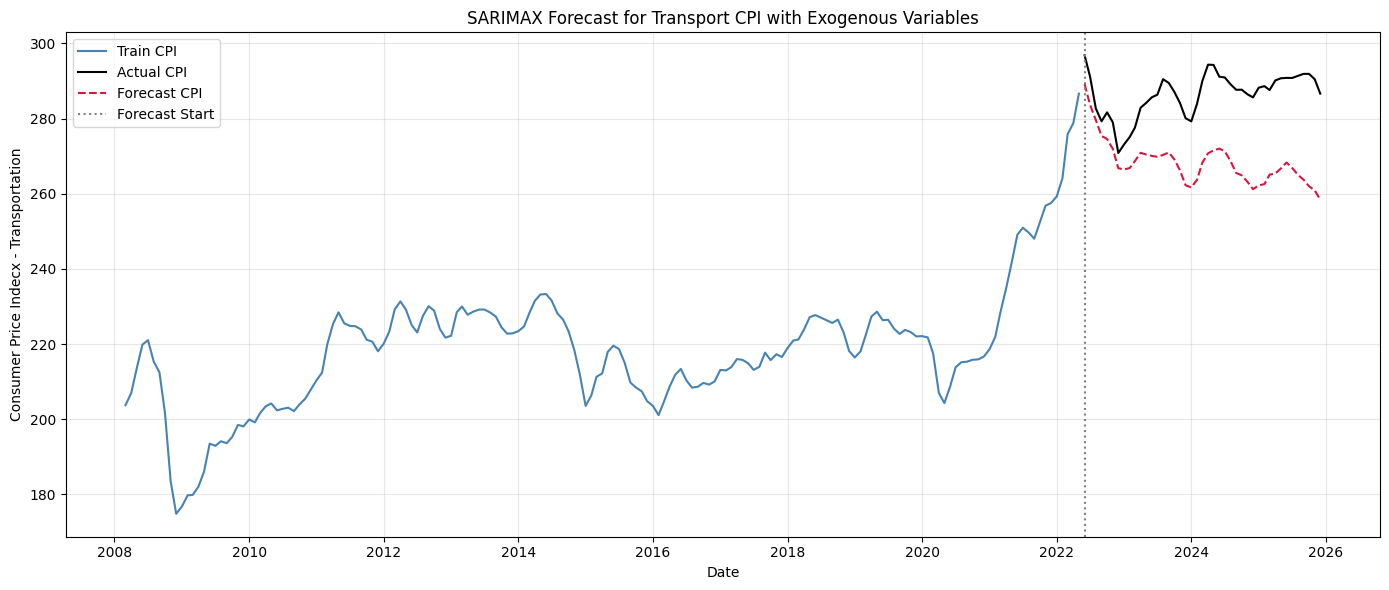

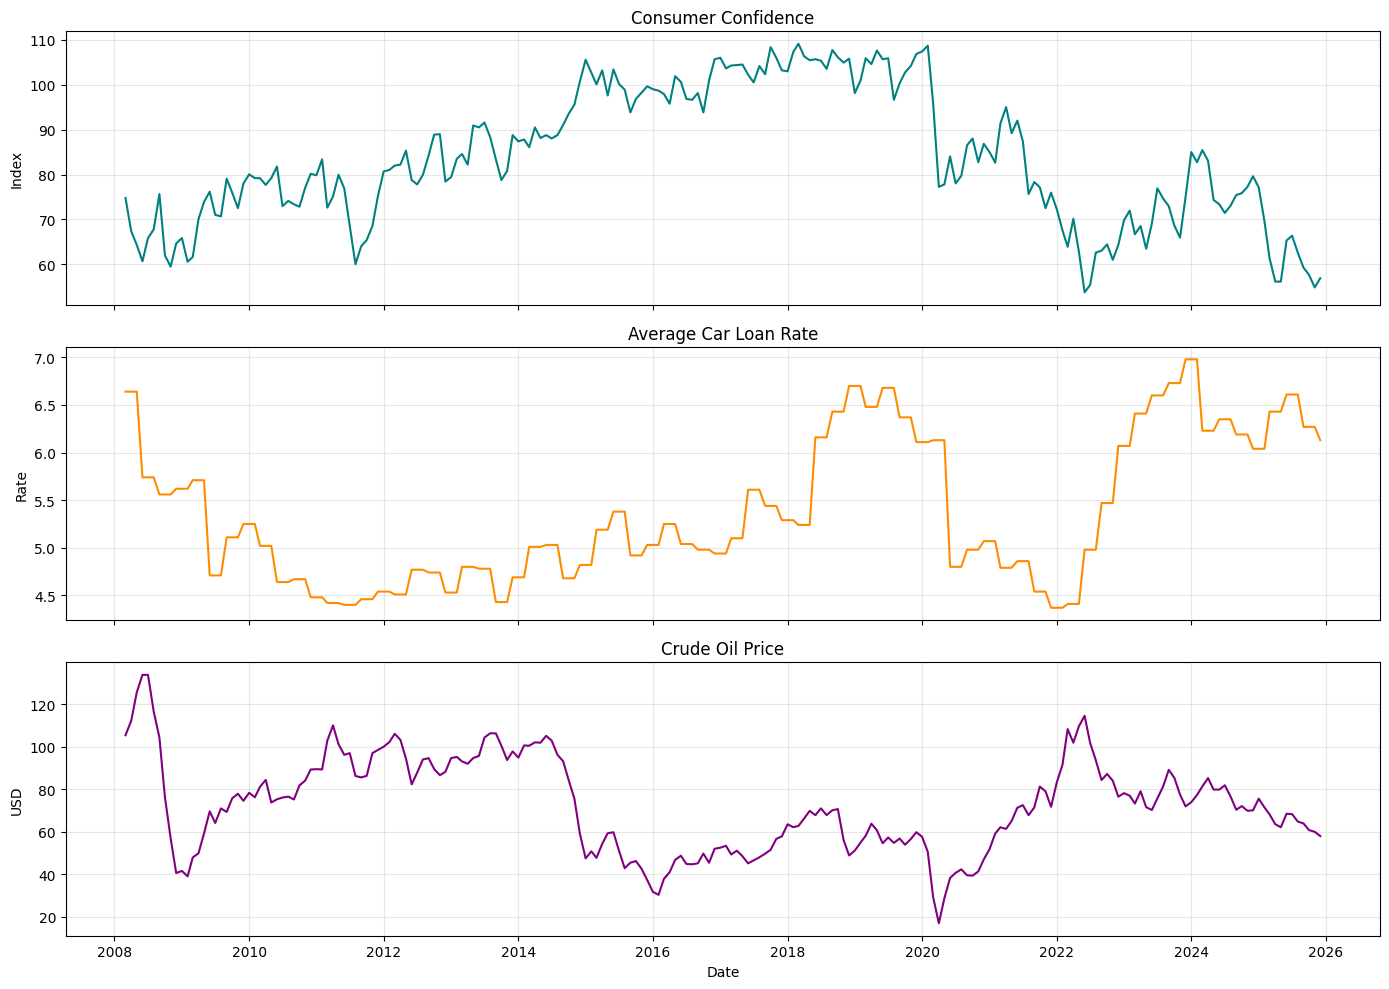

Model converged: True
AIC: -888.5208390493237


In [8]:
# Convert the actual log CPI test values back to the original CPI scale.
actual = np.exp(y_test)
# Build a results table with actual and forecast values.
results = pd.DataFrame({'Actual': actual, 'Forecast': pred}, index=y_test.index)
# Save the results table to a CSV file.
results.to_csv('output/sarimax_exog_forecast_with_plot.csv')
# Create a figure for the actual versus forecast comparison.
plt.figure(figsize=(14, 6))
# Plot the historical training CPI values.
plt.plot(y_train.index, np.exp(y_train), label='Train CPI', color='steelblue')
# Plot the actual test CPI values.
plt.plot(actual.index, actual, label='Actual CPI', color='black')
# Plot the forecasted CPI values.
plt.plot(pred.index, pred, label='Forecast CPI', color='crimson', linestyle='--')
# Add a vertical line to show the train-test split.
plt.axvline(actual.index[0], color='gray', linestyle=':', label='Forecast Start')
# Add a title to the forecast comparison chart.
plt.title('SARIMAX Forecast for Transport CPI with Exogenous Variables')
# Label the x-axis.
plt.xlabel('Date')
# Label the y-axis.
plt.ylabel('Consumer Price Indecx - Transportation')
# Show the legend on the chart.
plt.legend()
# Add a light grid for readability.
plt.grid(alpha=0.3)
# Tighten layout so labels fit well.
plt.tight_layout()
# Save the forecast comparison chart to a PNG file.
plt.savefig('output/sarimax_forecast_plot.png', dpi=150, bbox_inches='tight')
# Display the forecast comparison chart.
plt.show()
# Create subplots for the exogenous variables.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
# Plot consumer confidence on the first subplot.
axes[0].plot(data.index, data['ConsumerConfidence'], color='teal')
# Add a title to the consumer confidence subplot.
axes[0].set_title('Consumer Confidence')
# Add a y-axis label to the consumer confidence subplot.
axes[0].set_ylabel('Index')
# Add a light grid to the consumer confidence subplot.
axes[0].grid(alpha=0.3)
# Plot car loan rate on the second subplot.
axes[1].plot(data.index, data['CarLoanRate'], color='darkorange')
# Add a title to the car loan rate subplot.
axes[1].set_title('Average Car Loan Rate')
# Add a y-axis label to the car loan rate subplot.
axes[1].set_ylabel('Rate')
# Add a light grid to the car loan rate subplot.
axes[1].grid(alpha=0.3)
# Plot crude oil price on the third subplot.
axes[2].plot(data.index, data['CrudeOilPrice'], color='purple')
# Add a title to the crude oil price subplot.
axes[2].set_title('Crude Oil Price')
# Add a y-axis label to the crude oil price subplot.
axes[2].set_ylabel('USD')
# Add a label to the shared x-axis.
axes[2].set_xlabel('Date')
# Add a light grid to the crude oil price subplot.
axes[2].grid(alpha=0.3)
# Tighten the subplot layout.
plt.tight_layout()
# Save the exogenous variables chart to a PNG file.
plt.savefig('output/exogenous_variables_plot.png', dpi=150, bbox_inches='tight')
# Display the exogenous variables chart.
plt.show()
# Print whether the model converged successfully.
print('Model converged:', fit.mle_retvals['converged'])
# Print the AIC value for the fitted model.
print('AIC:', fit.aic)
